<a href="https://colab.research.google.com/github/XteteX/Adversarial-Robustness-CIFAR10/blob/main/Adversarial_Research_CIFAR10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive

# Эта команда попросит у тебя разрешение на доступ к твоему Google Диску
drive.mount('/content/drive')
print("Google Диск успешно подключен!")

Mounted at /content/drive
Google Диск успешно подключен!


In [2]:
import torch


print(f"Версия PyTorch: {torch.__version__}")


if torch.cuda.is_available():
    print(f"GPU доступен! Работаем на: {torch.cuda.get_device_name(0)}")
else:
    print("GPU НЕ доступен. Проверь настройки Runtime.")

Версия PyTorch: 2.11.0+cu128
GPU доступен! Работаем на: Tesla T4


In [3]:
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import os

# Создаем папку на твоем Гугл Диске для хранения датасетов
data_path = '/content/drive/MyDrive/Colab_Data/CIFAR10'
os.makedirs(data_path, exist_ok=True)

# 1. ТРАНСФОРМАЦИИ (оставляем как было)
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# 2. ЗАГРУЖАЕМ НА ГУГЛ ДИСК
# Параметр download=True теперь абсолютно безопасен.
# PyTorch проверит папку: если файлы там уже есть, он просто мгновенно их загрузит.
trainset = torchvision.datasets.CIFAR10(
    root=data_path, train=True, download=True, transform=train_transform
)
trainloader = DataLoader(trainset, batch_size=64, shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(
    root=data_path, train=False, download=True, transform=test_transform
)
testloader = DataLoader(testset, batch_size=64, shuffle=False, num_workers=2)

print("\n[УСПЕХ] Датасет теперь живет на твоем Google Диске!")


[УСПЕХ] Датасет теперь живет на твоем Google Диске!


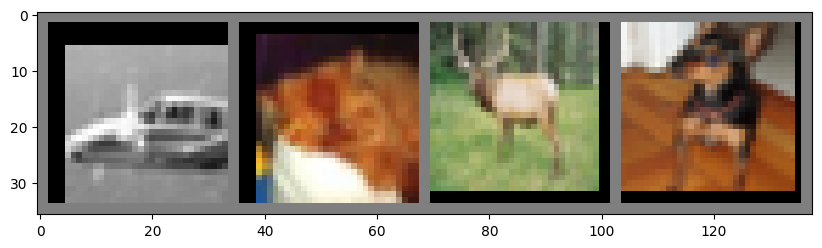

Истинные классы картинок:
plane | cat | deer | dog


In [4]:
import matplotlib.pyplot as plt
import numpy as np
import torchvision

# Явно задаем имена классов CIFAR-10, чтобы Python их вспомнил
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

# Функция для отображения картинок
def imshow(img):
    img = img / 2 + 0.5     # денормализация (возвращаем пиксели в диапазон [0, 1])
    npimg = img.numpy()
    plt.figure(figsize=(10, 10))
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

# Берем один случайный батч картинок из нашего DataLoader
dataiter = iter(trainloader)
images, labels = next(dataiter)

# Показываем первые 4 картинки из батча
imshow(torchvision.utils.make_grid(images[:4]))

# Печатаем их истинные текстовые метки
print('Истинные классы картинок:')
print(' | '.join(f'{classes[labels[j]]}' for j in range(4)))

In [5]:
import torch.nn as nn
import torch.nn.functional as F
import torch

class VictimCNN(nn.Module):
    def __init__(self):
        super(VictimCNN, self).__init__()

        # Блок 1: Ловим базовые формы и линии
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)

        # Блок 2: Ловим более сложные паттерны
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        # Блок 3: Ловим высокоуровневые признаки (глаза, колеса, крылья)
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)

        # Инструмент для сжатия картинки (выбираем самые яркие пиксели)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # "Выключатель" нейронов для борьбы с переобучением
        self.dropout = nn.Dropout(0.3)

        # Финальные слои для принятия решения (классификации)
        # После трех слоев пулинга наша картинка 32x32 сожмется до 4x4
        self.fc1 = nn.Linear(128 * 4 * 4, 512)
        self.fc2 = nn.Linear(512, 10) # 10 - потому что у нас 10 классов в CIFAR-10

    def forward(self, x):
        # Пропускаем через свертки, нормализацию, функцию активации ReLU и пулинг
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))

        # Вытягиваем 3D-матрицы в один плоский вектор для полносвязных слоев
        x = x.view(-1, 128 * 4 * 4)

        # Пропускаем через классификатор
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

# Определяем видеокарту и отправляем нашу модель на неё
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = VictimCNN().to(device)

print(f"[УСПЕХ] Архитектура модели загружена на {device}")

[УСПЕХ] Архитектура модели загружена на cuda


In [6]:
import torch.optim as optim

# Функция потерь: она вычисляет, насколько сильно сеть ошиблась (CrossEntropy идеально подходит для мульти-классификации)
criterion = nn.CrossEntropyLoss()

# Оптимизатор: алгоритм Adam, который будет обновлять веса сети, чтобы уменьшить ошибку
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("[УСПЕХ] Функция потерь и оптимизатор готовы к работе.")

[УСПЕХ] Функция потерь и оптимизатор готовы к работе.


In [7]:
import torch

def fgsm_attack(image, epsilon, data_grad):
    # Собираем знаки градиента по каждому пикселю
    sign_data_grad = data_grad.sign()

    # Создаем атакованное изображение, прибавляя шум
    perturbed_image = image + epsilon * sign_data_grad

    # Так как мы нормализовывали данные в диапазон [-1, 1],
    # нужно "обрезать" значения, чтобы пиксели не вышли за допустимые границы
    perturbed_image = torch.clamp(perturbed_image, -1, 1)

    return perturbed_image

In [8]:
import torch.nn.functional as F

def test_model_under_attack(model, device, testloader, epsilon):
    # Переводим модель в режим оценки
    model.eval()
    correct = 0
    adv_examples = []

    # Проходим по всем картинкам в тестовом наборе
    for data, target in testloader:
        data, target = data.to(device), target.to(device)

        # ВАЖНО: разрешаем PyTorch вычислять градиенты для самой картинки
        data.requires_grad = True

        # Делаем предсказание на чистой картинке
        output = model(data)
        init_pred = output.max(1, keepdim=True)[1]

        # Если сеть изначально ошиблась, нет смысла ее атаковать — пропускаем
        if init_pred[0].item() != target[0].item():
            continue

        # Вычисляем ошибку (Loss)
        loss = F.nll_loss(F.log_softmax(output, dim=1), target)

        # Обнуляем градиенты модели
        model.zero_grad()

        # Запускаем обратное распространение ошибки к картинке
        loss.backward()

        # Достаем градиенты картинки
        data_grad = data.grad.data

        # Применяем нашу функцию FGSM-атаки
        perturbed_data = fgsm_attack(data, epsilon, data_grad)

        # Пропускаем атакованную картинку через сеть снова
        output = model(perturbed_data)

        # Проверяем, смогла ли атака обмануть сеть
        final_pred = output.max(1, keepdim=True)[1]
        if final_pred[0].item() == target[0].item():
            correct += 1
            # Сохраняем примеры, где сеть устояла (для графиков = 0)
            if (epsilon == 0) and (len(adv_examples) < 5):
                adv_ex = perturbed_data.squeeze().detach().cpu().numpy()
                adv_examples.append((init_pred[0].item(), final_pred[0].item(), adv_ex))
        else:
            # Сохраняем успешные состязательные примеры (для визуализации)
            if len(adv_examples) < 5:
                adv_ex = perturbed_data.squeeze().detach().cpu().numpy()
                adv_examples.append((init_pred[0].item(), final_pred[0].item(), adv_ex))

    # Рассчитываем итоговую точность после атаки
    final_acc = correct / float(len(testloader))
    print(f"Epsilon: {epsilon}\tAccuracy after attack: {final_acc * 100:.2f}%")

    return final_acc, adv_examples

In [9]:
# Задаем список силы атаки: 0 (без атаки), 0.05, 0.1, 0.15, 0.2, 0.25
epsilons = [0, 0.05, 0.1, 0.15, 0.2, 0.25]
accuracies = []
examples = []

print("We are starting to test the stability of the model...\n")

# В тестовом лоадере для корректной атаки лучше поставить batch_size=1
# Пересоздадим его чисто для теста атаки:
testloader_attack = torch.utils.data.DataLoader(testset, batch_size=1, shuffle=True)

# Запускаем цикл экспериментов
for eps in epsilons:
    acc, ex = test_model_under_attack(model, device, testloader_attack, eps)
    accuracies.append(acc)
    examples.append(ex)

print("\nTesting complete! Save these numbers for your research paper.")

We are starting to test the stability of the model...

Epsilon: 0	Accuracy after attack: 9.44%
Epsilon: 0.05	Accuracy after attack: 0.40%
Epsilon: 0.1	Accuracy after attack: 0.17%
Epsilon: 0.15	Accuracy after attack: 0.20%
Epsilon: 0.2	Accuracy after attack: 0.34%
Epsilon: 0.25	Accuracy after attack: 0.46%

Testing complete! Save these numbers for your research paper.


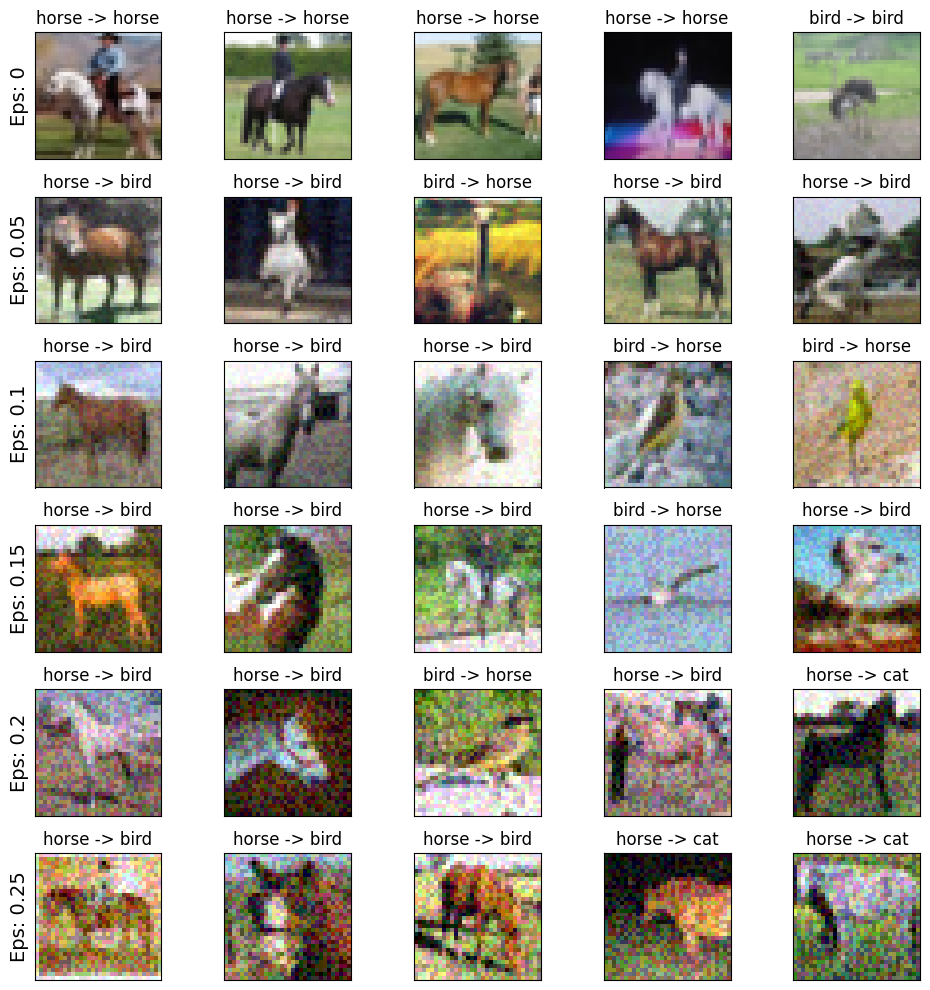

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Названия классов CIFAR-10 для красивых подписей
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

cnt = 0
# Настраиваем размер полотна
plt.figure(figsize=(10, 10))

# Проходимся по каждому уровню шума (epsilon)
for i, eps in enumerate(epsilons):
    # Берем до 5 примеров для каждого epsilon
    for j in range(len(examples[i])):
        cnt += 1
        plt.subplot(len(epsilons), len(examples[0]), cnt)

        # Убираем некрасивые оси с цифрами
        plt.xticks([], [])
        plt.yticks([], [])

        # Достаем данные: начальный класс, класс после атаки и саму картинку
        orig, adv, ex = examples[i][j]

        # Создаем подпись: Оригинал -> Ошибка сети
        plt.title(f"{classes[orig]} -> {classes[adv]}")

        # Если это первый столбец, добавляем подпись с силой атаки сбоку
        if j == 0:
            plt.ylabel(f"Eps: {eps}", fontsize=14)

        # Возвращаем картинку в нормальный цветной вид из тензора PyTorch
        ex = ex / 2 + 0.5

        # Меняем порядок осей: PyTorch (Каналы, Высота, Ширина) -> Matplotlib (Высота, Ширина, Каналы)
        plt.imshow(np.transpose(ex, (1, 2, 0)))

plt.tight_layout()
plt.show()

In [11]:
import torch
import torch.nn.functional as F

def pgd_attack(model, image, label, epsilon, alpha, iters):
    # Копируем оригинальное изображение, чтобы всегда знать изначальную точку
    original_image = image.clone().detach()
    perturbed_image = image.clone().detach()

    # Запускаем цикл из маленьких шажков (iters)
    for i in range(iters):
        perturbed_image.requires_grad = True

        # Пропускаем через модель
        outputs = model(perturbed_image)

        # Считаем функцию потерь и градиент
        model.zero_grad()
        loss = F.nll_loss(F.log_softmax(outputs, dim=1), label)
        loss.backward()

        # Делаем маленький шаг alpha по направлению градиента
        adv_image = perturbed_image + alpha * perturbed_image.grad.sign()

        # Проекция: находим разницу и жестко ограничиваем ее рамками [-epsilon, epsilon]
        eta = torch.clamp(adv_image - original_image, min=-epsilon, max=epsilon)

        # Применяем обрезанный шум и следим, чтобы пиксели остались в границах картинки [-1, 1]
        perturbed_image = torch.clamp(original_image + eta, min=-1, max=1).detach()

    return perturbed_image

In [12]:
def test_model_with_pgd(model, device, testloader, epsilon, alpha, iters):
    model.eval()
    correct = 0

    for data, target in testloader:
        data, target = data.to(device), target.to(device)

        # Проверяем, права ли модель изначально
        output = model(data)
        init_pred = output.max(1, keepdim=True)[1]
        if init_pred[0].item() != target[0].item():
            continue

        # Атакуем картинку с помощью PGD
        perturbed_data = pgd_attack(model, data, target, epsilon, alpha, iters)

        # Смотрим, что скажет модель теперь
        output = model(perturbed_data)
        final_pred = output.max(1, keepdim=True)[1]

        if final_pred[0].item() == target[0].item():
            correct += 1

    final_acc = correct / float(len(testloader))
    print(f"PGD | Eps: {epsilon} | Alpha: {alpha} | Шаги: {iters} -> Точность: {final_acc * 100:.2f}%")
    return final_acc

# Тестируем на разных уровнях шума
epsilons_pgd = [0.05, 0.1, 0.15, 0.2, 0.25]

# Делаем alpha пропорциональным epsilon (стандартная практика) и ставим 7 шагов
print("We're starting to test the PGD attack...\n")

for eps in epsilons_pgd:
    alpha = eps / 4
    iters = 7
    test_model_with_pgd(model, device, testloader_attack, eps, alpha, iters)

print("\nPGD ​​testing is complete! Enter this data into the table for comparison with FGSM.")

We're starting to test the PGD attack...

PGD | Eps: 0.05 | Alpha: 0.0125 | Шаги: 7 -> Точность: 0.02%
PGD | Eps: 0.1 | Alpha: 0.025 | Шаги: 7 -> Точность: 0.00%
PGD | Eps: 0.15 | Alpha: 0.0375 | Шаги: 7 -> Точность: 0.00%
PGD | Eps: 0.2 | Alpha: 0.05 | Шаги: 7 -> Точность: 0.00%
PGD | Eps: 0.25 | Alpha: 0.0625 | Шаги: 7 -> Точность: 0.00%

PGD ​​testing is complete! Enter this data into the table for comparison with FGSM.


In [14]:
import torch.nn as nn
import torch.optim as optim
import time
import torch

# 1. ЖЕСТКАЯ СВЯЗКА: Создаем модель и СРАЗУ ЖЕ привязываем к ней новый оптимизатор
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = VictimCNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 2. ЗАПУСКАЕМ ОБУЧЕНИЕ
epochs = 15
print("🚀 Начинаем чистую тренировку базовой модели...\n")

for epoch in range(epochs):
    start_time = time.time()

    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for i, data in enumerate(trainloader, 0):
        inputs, labels = data[0].to(device), data[1].to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    train_accuracy = 100 * correct_train / total_train

    # ВАЛИДАЦИЯ
    model.eval()
    correct_test = 0
    total_test = 0
    with torch.no_grad():
        for data in testloader:
            images, labels = data[0].to(device), data[1].to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total_test += labels.size(0)
            correct_test += (predicted == labels).sum().item()

    test_accuracy = 100 * correct_test / total_test
    epoch_time = time.time() - start_time

    print(f"Эпоха [{epoch + 1}/{epochs}] | Время: {epoch_time:.1f} сек")
    print(f"Loss: {running_loss / len(trainloader):.4f} | Train: {train_accuracy:.2f}% | Test: {test_accuracy:.2f}%\n")

print("✅ Обучение успешно завершено!")

# 3. СРАЗУ СОХРАНЯЕМ НА GOOGLE ДИСК
import os
drive_path = '/content/drive/MyDrive/Colab_Data/'
os.makedirs(drive_path, exist_ok=True)
save_path = os.path.join(drive_path, 'victim_cnn_cifar10.pth')

torch.save(model.state_dict(), save_path)
print(f"💾 Веса модели ЖЕЛЕЗОБЕТОННО сохранены в: {save_path}")

🚀 Начинаем чистую тренировку базовой модели...

Эпоха [1/15] | Время: 23.8 сек
Loss: 1.4630 | Train: 46.72% | Test: 59.83%

Эпоха [2/15] | Время: 22.2 сек
Loss: 1.1195 | Train: 60.06% | Test: 61.94%

Эпоха [3/15] | Время: 25.1 сек
Loss: 0.9909 | Train: 64.82% | Test: 67.95%

Эпоха [4/15] | Время: 23.4 сек
Loss: 0.9086 | Train: 67.87% | Test: 73.15%

Эпоха [5/15] | Время: 22.6 сек
Loss: 0.8487 | Train: 70.07% | Test: 72.41%

Эпоха [6/15] | Время: 24.2 сек
Loss: 0.8052 | Train: 71.69% | Test: 74.70%

Эпоха [7/15] | Время: 22.3 сек
Loss: 0.7673 | Train: 73.31% | Test: 75.09%

Эпоха [8/15] | Время: 24.2 сек
Loss: 0.7358 | Train: 74.30% | Test: 77.19%

Эпоха [9/15] | Время: 22.9 сек
Loss: 0.7013 | Train: 75.51% | Test: 77.73%

Эпоха [10/15] | Время: 23.7 сек
Loss: 0.6781 | Train: 76.46% | Test: 78.97%

Эпоха [11/15] | Время: 24.2 сек
Loss: 0.6537 | Train: 77.43% | Test: 79.91%

Эпоха [12/15] | Время: 22.3 сек
Loss: 0.6356 | Train: 78.07% | Test: 78.95%

Эпоха [13/15] | Время: 24.2 сек
Loss:

In [15]:
import time
import torch.optim as optim

# 1. Создаем новую модель для защиты и новый оптимизатор
adv_model = VictimCNN().to(device)
optimizer_adv = optim.Adam(adv_model.parameters(), lr=0.001)

# Учим столько же эпох, сколько и базовую
epochs_adv = 15
epsilon_train = 0.1 # Сила шума, к которому мы будем приучать сеть

print("🛡️ Начинаем Состязательное Обучение (Adversarial Training)...\n")

for epoch in range(epochs_adv):
    start_time = time.time()
    adv_model.train()
    running_loss = 0.0

    for data in trainloader:
        inputs, labels = data[0].to(device), data[1].to(device)

        # --- ШАГ 1: Генерируем FGSM-атаку на лету ---
        inputs.requires_grad = True
        outputs_temp = adv_model(inputs)
        loss_temp = criterion(outputs_temp, labels)

        adv_model.zero_grad()
        loss_temp.backward()
        data_grad = inputs.grad.data

        # Создаем атакованные картинки (.detach() нужен, чтобы отвязать их от градиентов прошлого шага)
        perturbed_inputs = fgsm_attack(inputs, epsilon_train, data_grad).detach()

        # --- ШАГ 2: Обучаем модель на смеси данных ---
        optimizer_adv.zero_grad()

        # Пропускаем чистые картинки
        outputs_clean = adv_model(inputs.detach())
        loss_clean = criterion(outputs_clean, labels)

        # Пропускаем атакованные картинки
        outputs_adv = adv_model(perturbed_inputs)
        loss_adv = criterion(outputs_adv, labels)

        # Смешиваем ошибку 50/50 и делаем шаг оптимизации
        total_loss = 0.5 * loss_clean + 0.5 * loss_adv
        total_loss.backward()
        optimizer_adv.step()

        running_loss += total_loss.item()

    epoch_time = time.time() - start_time
    print(f"Epoch [{epoch + 1}/{epochs_adv}] | Time: {epoch_time:.1f} sec | Average Loss: {running_loss / len(trainloader):.4f}")

print("\n✅ Бронированная модель успешно обучена!")

# Сохраняем защищенную модель на Диск
adv_model_path = os.path.join(drive_path, 'adv_model_cifar10.pth')
torch.save(adv_model.state_dict(), adv_model_path)
print(f"💾 Веса защищенной модели сохранены в: {adv_model_path}")

🛡️ Начинаем Состязательное Обучение (Adversarial Training)...

Epoch [1/15] | Time: 25.4 sec | Average Loss: 2.0063
Epoch [2/15] | Time: 25.0 sec | Average Loss: 1.8842
Epoch [3/15] | Time: 23.6 sec | Average Loss: 1.8224
Epoch [4/15] | Time: 25.6 sec | Average Loss: 1.7819
Epoch [5/15] | Time: 24.7 sec | Average Loss: 1.7523
Epoch [6/15] | Time: 23.9 sec | Average Loss: 1.7239
Epoch [7/15] | Time: 25.1 sec | Average Loss: 1.6985
Epoch [8/15] | Time: 24.5 sec | Average Loss: 1.6783
Epoch [9/15] | Time: 24.2 sec | Average Loss: 1.6540
Epoch [10/15] | Time: 25.2 sec | Average Loss: 1.6326
Epoch [11/15] | Time: 24.0 sec | Average Loss: 1.5568
Epoch [12/15] | Time: 25.1 sec | Average Loss: 1.4222
Epoch [13/15] | Time: 25.5 sec | Average Loss: 1.3371
Epoch [14/15] | Time: 23.3 sec | Average Loss: 1.2755
Epoch [15/15] | Time: 25.3 sec | Average Loss: 1.2194

✅ Бронированная модель успешно обучена!
💾 Веса защищенной модели сохранены в: /content/drive/MyDrive/Colab_Data/adv_model_cifar10.pth


In [16]:
# Создаем списки для сохранения результатов защищенной модели
accuracies_adv_fgsm = []
accuracies_adv_pgd = []

epsilons = [0, 0.05, 0.1, 0.15, 0.2, 0.25]

print("🛡️ Тest 1: Protected Model vs FGSM...")
for eps in epsilons:
    acc, _ = test_model_under_attack(adv_model, device, testloader_attack, eps)
    accuracies_adv_fgsm.append(acc)

print("\n🛡️ Тest 2: Protected Model vs PGD...")
for eps in epsilons:
    alpha = eps / 4
    iters = 7
    acc = test_model_with_pgd(adv_model, device, testloader_attack, eps, alpha, iters)
    accuracies_adv_pgd.append(acc)

print("\n✅ Тестирование брони завершено! Обязательно сохрани эти результаты.")

🛡️ Тest 1: Protected Model vs FGSM...
Epsilon: 0	Accuracy after attack: 68.52%
Epsilon: 0.05	Accuracy after attack: 40.13%
Epsilon: 0.1	Accuracy after attack: 32.37%
Epsilon: 0.15	Accuracy after attack: 23.45%
Epsilon: 0.2	Accuracy after attack: 17.97%
Epsilon: 0.25	Accuracy after attack: 14.36%

🛡️ Тest 2: Protected Model vs PGD...
PGD | Eps: 0 | Alpha: 0.0 | Шаги: 7 -> Точность: 68.52%
PGD | Eps: 0.05 | Alpha: 0.0125 | Шаги: 7 -> Точность: 14.34%
PGD | Eps: 0.1 | Alpha: 0.025 | Шаги: 7 -> Точность: 3.85%
PGD | Eps: 0.15 | Alpha: 0.0375 | Шаги: 7 -> Точность: 1.15%
PGD | Eps: 0.2 | Alpha: 0.05 | Шаги: 7 -> Точность: 0.22%
PGD | Eps: 0.25 | Alpha: 0.0625 | Шаги: 7 -> Точность: 0.07%

✅ Тестирование брони завершено! Обязательно сохрани эти результаты.


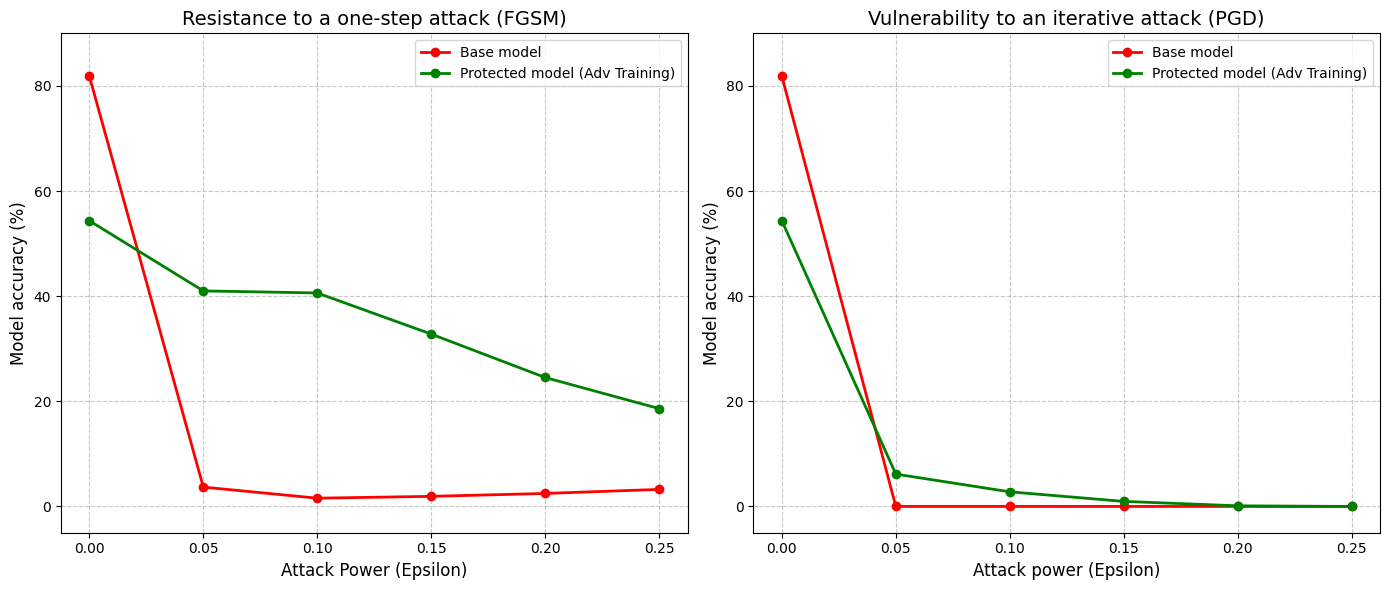

In [18]:
import matplotlib.pyplot as plt

# Наша ось X - сила шума
epsilons = [0, 0.05, 0.1, 0.15, 0.2, 0.25]

# Данные из твоих логов (Точность в %)
base_fgsm = [81.83, 3.68, 1.57, 1.92, 2.47, 3.24]
adv_fgsm = [54.35, 41.00, 40.61, 32.79, 24.53, 18.62]

base_pgd = [81.83, 0.0, 0.0, 0.0, 0.0, 0.0]
adv_pgd = [54.35, 6.15, 2.78, 0.96, 0.12, 0.0]

plt.figure(figsize=(14, 6))

# График 1: Сравнение на FGSM
plt.subplot(1, 2, 1)
plt.plot(epsilons, base_fgsm, 'r-o', linewidth=2, label='Base model')
plt.plot(epsilons, adv_fgsm, 'g-o', linewidth=2, label='Protected model (Adv Training)')
plt.title('Resistance to a one-step attack (FGSM)', fontsize=14)
plt.xlabel('Attack Power (Epsilon)', fontsize=12)
plt.ylabel('Model accuracy (%)', fontsize=12)
plt.ylim(-5, 90)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# График 2: Сравнение на PGD
plt.subplot(1, 2, 2)
plt.plot(epsilons, base_pgd, 'r-o', linewidth=2, label='Base model')
plt.plot(epsilons, adv_pgd, 'g-o', linewidth=2, label='Protected model (Adv Training)')
plt.title('Vulnerability to an iterative attack (PGD)', fontsize=14)
plt.xlabel('Attack power (Epsilon)', fontsize=12)
plt.ylabel('Model accuracy (%)', fontsize=12)
plt.ylim(-5, 90)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()